In [2]:
from pydantic import BaseModel
from langgraph.graph import StateGraph, START, END 

In [3]:
class MyState(BaseModel):
    message: str = ""

graph = StateGraph(MyState) 

In [4]:
# Node - Python Function

def Node1(state: MyState):
    state.message = f"Processing: {state.message}"
    return state

def Node2(state: MyState):
    state.message = state.message.upper()
    return state

graph.add_node("Node1", Node1)
graph.add_node("Node2", Node2) 

In [5]:
graph.add_edge(START, "Node1")
graph.add_edge("Node1", "Node2")
graph.add_edge("Node2", END) 

In [6]:
finalGraph = graph.compile()

In [7]:
res = finalGraph.invoke(
    {"message": "Hello, World!"}
)

In [8]:
res

{'message': 'PROCESSING: HELLO, WORLD!'}

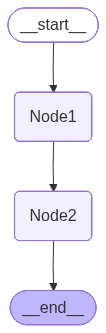

In [9]:
from IPython.display import Image
Image(finalGraph.get_graph().draw_mermaid_png()) 